In [2]:
import glob
import json
import os
import pandas as pd
import numpy as np
from pathlib import Path
import jinja2
from IPython.display import display, HTML


In [3]:
def set_project_root(marker="main.py"):
    """
    Finds the project root by searching upwards for a specific marker
    and sets the current working directory.
    """
    current_dir = Path.cwd()

    # Iterate through the current directory and all its parents
    for path in [current_dir, *current_dir.parents]:
        if (path / marker).exists():
            os.chdir(path)
            print(f"Working directory set to: {path}")
            return path

    print(f"Marker '{marker}' not found. Working directory remains: {current_dir}")
    return current_dir

# Execute the function
set_project_root()

Working directory set to: /home/ruben-eschauzier/data-processing/process-raw-caching-jbr-output


PosixPath('/home/ruben-eschauzier/data-processing/process-raw-caching-jbr-output')

In [4]:
def find_failing_queries_per_template(file_path):
    """
    Counts the number of failed queries per template in a JSON file.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        dict: A dictionary mapping template names to their failure counts.
    """
    failure_counts = {}

    with open(file_path, 'r') as file:
        data = json.load(file)

    for entry in data:
        if "error" in entry:
            # Safely navigate the nested dictionary
            template = entry.get("sequenceElement", {}).get("template")

            if template:
                # Initialize to 0 if template is new, then add 1
                failure_counts[template] = failure_counts.get(template, 0) + 1

    return dict(sorted(failure_counts.items()))


def compare_failures_across_files(directory_path):
    """
    Reads all .json files in a directory, extracts failure counts,
    and returns a pandas DataFrame for comparison.
    """
    all_results = {}

    # Locate all JSON files in the target directory
    file_pattern = os.path.join(directory_path, '*.json')
    json_files = glob.glob(file_pattern)

    for file_path in json_files:
        file_name = os.path.basename(file_path)
        # Extract failure counts for the current file
        counts = find_failing_queries_per_template(file_path)
        all_results[file_name] = counts

    # Convert the nested dictionary to a DataFrame
    # This automatically aligns the templates (rows) and files (columns)
    df = pd.DataFrame(all_results)

    # Replace NaN values with 0 and convert to integers
    df = df.fillna(0).astype(int)

    # Sort the index (templates) alphabetically
    df = df.sort_index()

    return df

def find_failing_queries(file_path, target_template):
    """
    Extracts failing queries for a specific template from a JSON file.

    Args:
        file_path (str): The path to the JSON file.
        target_template (str): The template name to filter by (e.g., 'interactive-discover-8').

    Returns:
        list: A list of dictionaries representing the failing queries.
    """
    # Load the JSON data
    with open(file_path, 'r') as file:
        data = json.load(file)

    failing_queries = []

    # Iterate through entries and filter
    for entry in data:
        if "error" in entry:
            sequence_element = entry.get("sequenceElement", {})
            template = sequence_element.get("template")

            if template == target_template:
                # Remove the clutter
                entry.pop("sequenceInstantiationCounts")
                failing_queries.append(entry)

    return failing_queries


In [5]:
failing_queries_all_runs = compare_failures_across_files("data")
failing_queries_all_runs

,query-results-raw-query-cache-s.json,query-results-raw-default.json,query-results-raw-cache-s.json,query-results-raw-query-cache-estimate-s.json
interactive-discover-1,3,0,4,4
interactive-discover-2,0,0,1,0
interactive-discover-5,40,40,40,40
interactive-discover-6,30,30,35,29
interactive-discover-7,40,40,40,40
interactive-discover-8,10,0,0,13
interactive-short-2,90,90,90,89
interactive-short-3,140,140,140,140
interactive-short-6,190,190,190,190
interactive-short-7,180,180,180,179


In [6]:
# Compare to failures with default
# failing_discover_8_default= find_failing_queries("data/query-results-raw-default.json",
#                                                                "interactive-discover-8")
# failing_discover_8_default


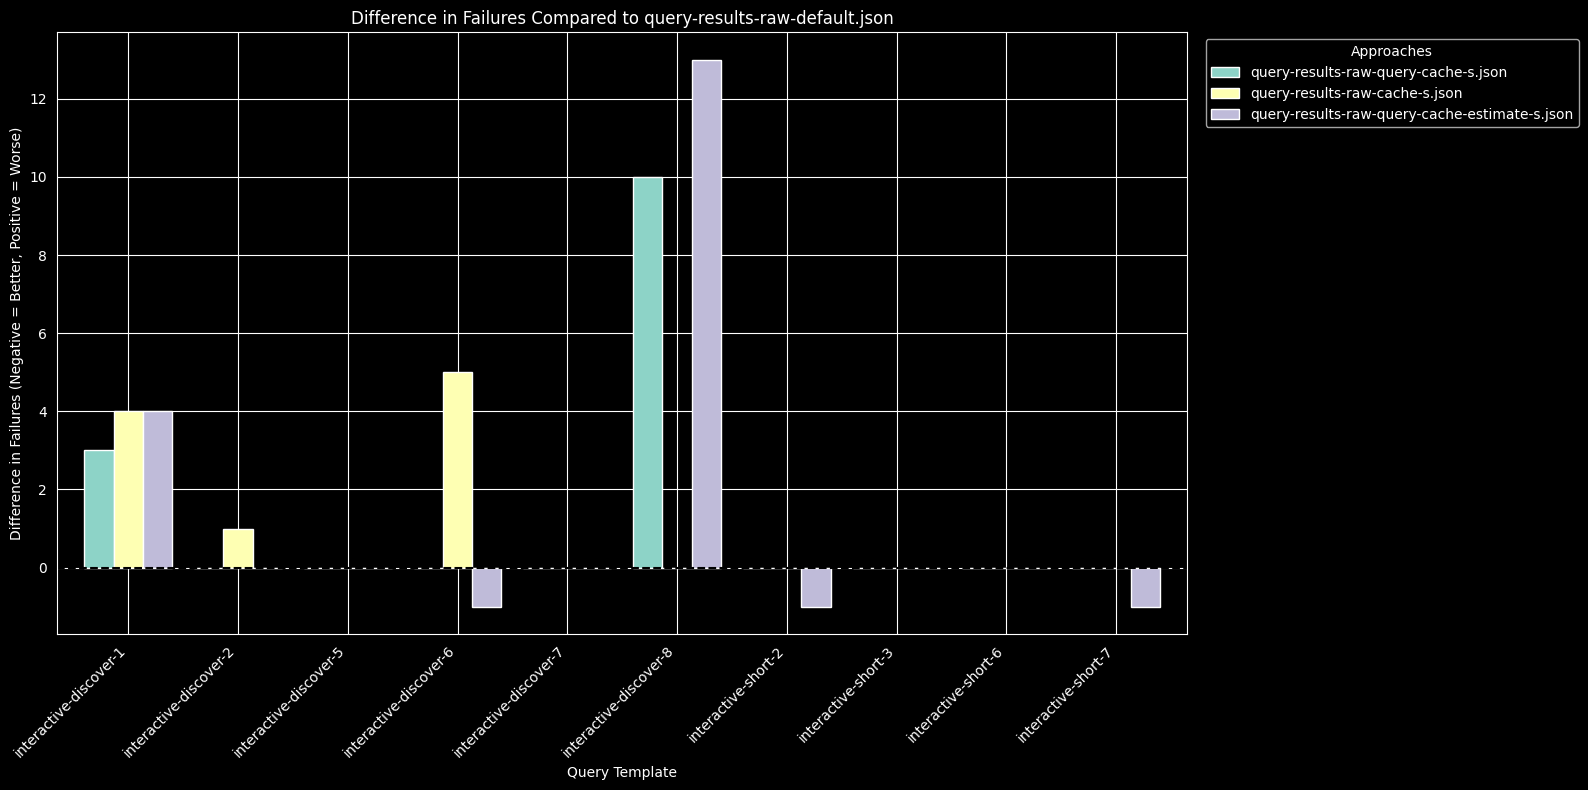

In [7]:
from matplotlib import pyplot as plt

def plot_baseline_differences(df, baseline_column):
    """
    Plots the difference in failure counts between various approaches and a baseline
    using a vertical grouped bar chart.
    """
    if baseline_column not in df.columns:
        raise ValueError(f"Baseline '{baseline_column}' not found.")

    # Calculate the difference from the baseline
    df_diff = df.drop(columns=[baseline_column]).subtract(df[baseline_column], axis=0)

    # Create a vertical grouped bar chart with a wider figure size
    fig, ax = plt.subplots(figsize=(16, 8))
    df_diff.plot(kind='bar', ax=ax, width=0.8)

    # Add a horizontal line at 0 to mark the baseline
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    # Formatting
    ax.set_title(f'Difference in Failures Compared to {baseline_column}')
    ax.set_ylabel('Difference in Failures (Negative = Better, Positive = Worse)')
    ax.set_xlabel('Query Template')

    # Rotate x-axis labels to ensure readability
    plt.xticks(rotation=45, ha='right')

    # Place legend outside the plot area
    ax.legend(title='Approaches', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_baseline_differences(failing_queries_all_runs, "query-results-raw-default.json")

In [8]:
# Get the per template execution time and hit rate
import os
import json
from typing import Literal
import pandas as pd
import numpy as np
from IPython.display import HTML, display

def generate_comparison_dfs_pooled(files, filterMode: Literal["refinement", "non-refinement"]):
    """
    Parses result files, pools variance across specific query instantiations
    identified by template, name, and id, and generates a DataFrame for each cache type.
    """
    all_results = {}

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        records = []
        for entry in data:
            refinement_metadata = entry.get("sequenceElement").get("refinementMetadata").get("patternIds")
            if refinement_metadata and filterMode == "refinement":
                continue
            if not refinement_metadata and filterMode == 'non-refinement':
                continue

            template = entry.get("sequenceElement", {}).get("template")
            q_name = entry.get("name")
            q_id = entry.get("id")
            exec_time = entry.get("time")

            cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                        entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

            hit_rate = np.nan
            if cache_str:
                try:
                    cache_stats = json.loads(cache_str)
                    hits = cache_stats.get("hits", 0)
                    total = hits + cache_stats.get("misses", 0)
                    hit_rate = (hits / total) if total > 0 else 0.0
                except json.JSONDecodeError:
                    pass

            # Ensure all composite keys exist before appending
            if template and q_name is not None and q_id is not None and exec_time is not None:
                records.append({
                    'template': template,
                    'name': q_name,
                    'id': q_id,
                    'time_s': exec_time / 1000,
                    'hit_rate': hit_rate
                })

        if not records:
            continue

        df_records = pd.DataFrame(records)
        # Calculate variance and mean per exact instantiation (template + name + id)
        inst_stats = df_records.groupby(['template', 'name', 'id']).agg(
            n=('time_s', 'count'),
            var_time=('time_s', 'var'),
            mean_time=('time_s', 'mean'),
            mean_hr=('hit_rate', 'mean')
        ).reset_index()

        inst_stats['var_time'] = inst_stats['var_time'].fillna(0)

        # 3. Pool the metrics up to the template level
        def pool_metrics(group):
            total_weight = (group['n'] - 1).sum()
            if total_weight > 0:
                pooled_var = ((group['n'] - 1) * group['var_time']).sum() / total_weight
            else:
                pooled_var = 0.0

            return pd.Series({
                'Avg Time (s)': group['mean_time'].mean(),
                'Std Time (s)': np.sqrt(pooled_var),
                'Avg Hit Rate': group['mean_hr'].mean()
            })

        template_metrics = inst_stats.groupby('template').apply(pool_metrics, include_groups=False).to_dict('index')
        all_results[label] = template_metrics

    # 4. Group by cache type
    baselines = ['default', 'default-n-b']
    cache_groups = {}

    for label in all_results.keys():
        if label in baselines:
            continue
        if label.endswith(('-s', '-m', '-l')):
            cache_type = label[:-2]
            if cache_type not in cache_groups:
                cache_groups[cache_type] = []
            cache_groups[cache_type].append(label)

    dfs_dict = {}
    size_order = {'s': 0, 'm': 1, 'l': 2}

    for cache_type, labels in cache_groups.items():
        sorted_labels = sorted(labels, key=lambda x: size_order.get(x[-1], 3))
        columns_to_include = [b for b in baselines if b in all_results] + sorted_labels

        reformatted = {
            (algo, metric): {tmpl: all_results.get(algo, {}).get(tmpl, {}).get(metric, np.nan)
                             for tmpl in all_results.get(algo, {})}
            for algo in columns_to_include
            for metric in ['Avg Time (s)', 'Std Time (s)', 'Avg Hit Rate']
        }
        dfs_dict[cache_type] = pd.DataFrame(reformatted).sort_index()

    return dfs_dict

def generate_comparison_dfs(files):
    """
    Parses result files and generates a separate DataFrame for each cache type,
    comparing its sizes against the default baselines.
    """
    all_results = {}

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        template_data = {}
        for entry in data:
            template = entry.get("sequenceElement", {}).get("template")
            exec_time = entry.get("time")

            cache_str = entry.get("@comunica/persistent-cache-manager:sourceState")
            if not cache_str:
                cache_str = entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

            hit_rate = np.nan
            if cache_str:
                try:
                    cache_stats = json.loads(cache_str)
                    hits = cache_stats.get("hits", 0)
                    misses = cache_stats.get("misses", 0)
                    total = hits + misses
                    hit_rate = (hits / total) if total > 0 else 0.0
                except json.JSONDecodeError:
                    pass

            if template and exec_time is not None:
                if template not in template_data:
                    template_data[template] = {'times': [], 'hit_rates': []}
                template_data[template]['times'].append(exec_time)
                if not np.isnan(hit_rate):
                    template_data[template]['hit_rates'].append(hit_rate)

        avg_metrics = {}
        for tmpl, metrics in template_data.items():
            avg_time = (sum(metrics['times']) / len(metrics['times'])) / 1000
            avg_hr = sum(metrics['hit_rates']) / len(metrics['hit_rates']) if metrics['hit_rates'] else np.nan
            avg_metrics[tmpl] = {'Avg Time (s)': avg_time, 'Avg Hit Rate': avg_hr}

        all_results[label] = avg_metrics

    baselines = ['default', 'default-n-b']
    cache_groups = {}

    for label in all_results.keys():
        if label in baselines:
            continue

        # Extract cache type assuming format: {cache_type}-{size}
        if label.endswith(('-s', '-m', '-l')):
            cache_type = label[:-2]
            if cache_type not in cache_groups:
                cache_groups[cache_type] = []
            cache_groups[cache_type].append(label)

    # Create a DataFrame for each cache type
    dfs_dict = {}
    size_order = {'s': 0, 'm': 1, 'l': 2}

    for cache_type, labels in cache_groups.items():
        # Sort labels by size: -s, -m, -l
        sorted_labels = sorted(labels, key=lambda x: size_order.get(x[-1], 3))
        columns_to_include = [b for b in baselines if b in all_results] + sorted_labels

        reformatted = {
            (algo, metric): {tmpl: all_results[algo][tmpl].get(metric, np.nan) for tmpl in all_results[algo]}
            for algo in columns_to_include
            for metric in ['Avg Time (s)', 'Avg Hit Rate']
        }
        dfs_dict[cache_type] = pd.DataFrame(reformatted).sort_index()

    return dfs_dict

def display_comparison_dfs(dfs_dict):
    """
    Iterates through the dictionary and displays each DataFrame
    as an HTML table with a clear heading.
    """
    for cache_type, df in dfs_dict.items():
        # Print a clear heading for the cache type
        display(HTML(f"<h3>Cache Type: {cache_type.upper()}</h3>"))

        # Display the actual DataFrame
        display(df)

files = glob.glob("data/*.json")
df_avg_times = generate_comparison_dfs_pooled(files, "refinement")
display_comparison_dfs(df_avg_times)

default                                cache-s  \
                       Avg Time (s) Std Time (s) Avg Hit Rate Avg Time (s)   
interactive-discover-1     4.139340     1.397918          NaN    12.812360   
interactive-discover-2     3.275590     0.314418          NaN     5.260340   
interactive-discover-3     4.324083     0.272224          NaN     4.456733   
interactive-discover-4     1.962585     0.203917          NaN     1.880569   
interactive-discover-5     1.879627     0.165970          NaN     1.746827   
interactive-discover-6    68.501311    28.922558          NaN    73.622944   
interactive-discover-7   103.453014     0.108787          NaN   103.433171   
interactive-discover-8    19.915713     6.300176          NaN    15.527213   
interactive-short-1        2.112844     0.175412          NaN     2.157744   
interactive-short-2      180.551400     1.200149          NaN   180.556767   
interactive-short-3      181.355975     2.525882          NaN   181.267463   
interactive-short-4        0.366885     0.301149          NaN     0.301715   
interactive-short-5        1.106536     0.081764          NaN     0.643664   
interactive-short-6      180.164908     0.640149          NaN   180.108538   
interactive-short-7      182.206925     3.065808          NaN   181.990492   

                                                  
                       Std Time (s) Avg Hit Rate  
interactive-discover-1    18.551683     0.643102  
interactive-discover-2    17.290652     0.461083  
interactive-discover-3     0.921912     0.089620  
interactive-discover-4     0.791030     0.289025  
interactive-discover-5     0.338258     0.322211  
interactive-discover-6    25.594061     0.202695  
interactive-discover-7     0.150281     0.025704  
interactive-discover-8     3.895774     0.156818  
interactive-short-1        0.456500     0.068077  
interactive-short-2        1.800149     0.016198  
interactive-short-3        2.248570     0.082430  
interactive-short-4        0.199051     0.587202  
interactive-short-5        0.444460     0.849403  
interactive-short-6        0.610759     0.020363  
interactive-short-7        2.944175     0.114750

default                            \
                       Avg Time (s) Std Time (s) Avg Hit Rate   
interactive-discover-1     4.139340     1.397918          NaN   
interactive-discover-2     3.275590     0.314418          NaN   
interactive-discover-3     4.324083     0.272224          NaN   
interactive-discover-4     1.962585     0.203917          NaN   
interactive-discover-5     1.879627     0.165970          NaN   
interactive-discover-6    68.501311    28.922558          NaN   
interactive-discover-7   103.453014     0.108787          NaN   
interactive-discover-8    19.915713     6.300176          NaN   
interactive-short-1        2.112844     0.175412          NaN   
interactive-short-2      180.551400     1.200149          NaN   
interactive-short-3      181.355975     2.525882          NaN   
interactive-short-4        0.366885     0.301149          NaN   
interactive-short-5        1.106536     0.081764          NaN   
interactive-short-6      180.164908     0.640149          NaN   
interactive-short-7      182.206925     3.065808          NaN   

                       query-cache-estimate-s                            
                                 Avg Time (s) Std Time (s) Avg Hit Rate  
interactive-discover-1              14.318910    19.728184     0.588871  
interactive-discover-2               4.476840     1.022006     0.558565  
interactive-discover-3               5.748950     1.307611     0.127669  
interactive-discover-4               1.845346     0.536838     0.326767  
interactive-discover-5               2.144518     0.620096     0.229160  
interactive-discover-6              65.002700    31.080525     0.293046  
interactive-discover-7             103.717957     1.067073     0.042494  
interactive-discover-8              58.414025    37.463351     0.193053  
interactive-short-1                  2.271089     0.585874     0.071045  
interactive-short-2                180.247911    19.638712     0.097580  
interactive-short-3                180.980800     2.657488     0.060398  
interactive-short-4                  0.420854     0.566520     0.580647  
interactive-short-5                  0.501173     0.335036     0.883370  
interactive-short-6                180.141546     0.699943     0.030808  
interactive-short-7                178.751400    16.489509     0.053306

default                           query-cache-s  \
                       Avg Time (s) Std Time (s) Avg Hit Rate  Avg Time (s)   
interactive-discover-1     4.139340     1.397918          NaN     11.871140   
interactive-discover-2     3.275590     0.314418          NaN      4.311950   
interactive-discover-3     4.324083     0.272224          NaN      5.000833   
interactive-discover-4     1.962585     0.203917          NaN      1.826892   
interactive-discover-5     1.879627     0.165970          NaN      1.949255   
interactive-discover-6    68.501311    28.922558          NaN     67.556056   
interactive-discover-7   103.453014     0.108787          NaN    103.560057   
interactive-discover-8    19.915713     6.300176          NaN     52.871700   
interactive-short-1        2.112844     0.175412          NaN      2.281844   
interactive-short-2      180.551400     1.200149          NaN    181.246067   
interactive-short-3      181.355975     2.525882          NaN    181.343163   
interactive-short-4        0.366885     0.301149          NaN      0.332831   
interactive-short-5        1.106536     0.081764          NaN      0.529027   
interactive-short-6      180.164908     0.640149          NaN    180.120900   
interactive-short-7      182.206925     3.065808          NaN    182.388108   

                                                  
                       Std Time (s) Avg Hit Rate  
interactive-discover-1    19.162103     0.646471  
interactive-discover-2     1.095310     0.486581  
interactive-discover-3     0.997870     0.084221  
interactive-discover-4     0.355313     0.310448  
interactive-discover-5     0.608796     0.300942  
interactive-discover-6    35.597003     0.195980  
interactive-discover-7     0.688015     0.023101  
interactive-discover-8    17.794805     0.205500  
interactive-short-1        0.580165     0.125300  
interactive-short-2        2.893870     0.014974  
interactive-short-3        2.622143     0.123369  
interactive-short-4        0.255785     0.604459  
interactive-short-5        0.301715     0.848538  
interactive-short-6        0.514926     0.029193  
interactive-short-7        3.252351     0.111748

In [9]:
import os
import json
import pandas as pd
from typing import Literal

def extract_raw_metrics(files, filter_mode: Literal["refinement", "non-refinement", "all"] = "all", target_file: str = None):
    """
    Parses result files and aggregates raw execution times into lists.
    Optionally limits parsing to a single specified file.
    """
    records = []

    if target_file:
        files = [f for f in files if target_file in f]

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        for entry in data:
            seq_element = entry.get("sequenceElement") or {}
            ref_metadata = seq_element.get("refinementMetadata") or {}
            pattern_ids = ref_metadata.get("patternIds")

            if filter_mode == "refinement" and pattern_ids:
                continue
            if filter_mode == "non-refinement" and not pattern_ids:
                continue
            template = seq_element.get("template")
            q_name = entry.get("name")
            q_id = entry.get("id")
            exec_time = entry.get("time")
            cache_str = entry.get("@comunica/persistent-cache-manager:sourceState")
            if not cache_str:
                cache_str = entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")
            is_error = True if entry.get("error") else False
            hit_rate = np.nan
            if cache_str:
                try:
                    cache_stats = json.loads(cache_str)
                    hits = cache_stats.get("hits", 0)
                    misses = cache_stats.get("misses", 0)
                    total = hits + misses
                    hit_rate = (hits / total) if total > 0 else 0.0
                except json.JSONDecodeError:
                    print("ERROR")
                    pass

            if template and q_name is not None and q_id is not None and exec_time is not None:
                records.append({
                    'label': label,
                    'template': template,
                    'name': q_name,
                    'id': q_id,
                    'time_s': exec_time / 1000,
                    'hit_rate': hit_rate,
                    'error': is_error
                })

    if not records:
        return pd.DataFrame()

    df_records = pd.DataFrame(records)
    df_records['hit_rate'] = df_records['hit_rate'].round(2)

    raw_times_df = df_records.groupby(
        ['label', 'template', 'name', 'id']
    )['time_s'].apply(list).reset_index()

    raw_hit_rates_df = df_records.groupby(
        ['label', 'template', 'name', 'id']
    )['hit_rate'].apply(list).reset_index()

    raw_error_df = df_records.groupby(
        ['label', 'template', 'name', 'id']
    )['error'].apply(list).reset_index()

    raw_times_df.rename(columns={'time_s': 'execution_times_s'}, inplace=True)
    raw_times_df['execution_count'] = raw_times_df['execution_times_s'].apply(len)

    return raw_times_df, raw_hit_rates_df, raw_error_df

In [11]:
files = glob.glob("data/*.json")

# Remove column width limits to display full lists
pd.set_option('display.max_colwidth', None)
df_raw_rh, df_hit_rate_rh, df_error_rh = extract_raw_metrics(files, "refinement", target_file="query-results-raw-cache-s.json")


# Display the raw lists for a specific template or cache label
print("Cache Small")
display(df_raw_rh[df_raw_rh["name"] == "sequence_0"])

# display(df_error[df_error["name"] == "sequence_0"])
# Display hit rates
# display(df_hit_rate[df_hit_rate["name"] == "sequence_0"])
pd.reset_option('display.max_colwidth')

Cache Small


,label,template,name,id,execution_times_s,execution_count
0,cache-s,interactive-discover-1,sequence_0,7,"[1.155, 1.485, 0.906, 1.012, 1.131, 0.989, 1.107, 1.006, 0.981, 1.087]",10
20,cache-s,interactive-discover-3,sequence_0,3,"[9.633, 10.171, 10.455, 6.562, 6.266, 6.749, 7.344, 5.687, 7.057, 7.143]",10
26,cache-s,interactive-discover-4,sequence_0,15,"[9.135, 1.871, 1.709, 1.78, 1.276, 1.732, 1.565, 1.288, 1.885, 1.334]",10
27,cache-s,interactive-discover-4,sequence_0,4,"[0.813, 0.887, 0.859, 0.85, 0.883, 0.797, 0.736, 0.907, 0.85, 0.856]",10
39,cache-s,interactive-discover-5,sequence_0,6,"[0.475, 0.47, 1.547, 1.575, 0.471, 0.44, 1.261, 1.375, 1.582, 1.281]",10
50,cache-s,interactive-discover-6,sequence_0,13,"[180.033, 180.702, 180.036, 180.031, 180.023, 180.018, 180.03, 180.025, 180.038, 180.018]",10
51,cache-s,interactive-discover-6,sequence_0,14,"[49.435, 180.117, 180.115, 180.022, 53.639, 180.115, 180.117, 55.07, 180.116, 46.786]",10
59,cache-s,interactive-discover-7,sequence_0,5,"[180.065, 180.035, 180.036, 180.031, 180.031, 180.035, 180.033, 180.037, 180.807, 180.036]",10
66,cache-s,interactive-discover-8,sequence_0,24,"[26.645, 24.629, 18.323, 18.895, 18.777, 24.951, 35.854, 20.487, 18.451, 24.558]",10
67,cache-s,interactive-discover-8,sequence_0,9,"[16.739, 16.514, 14.837, 14.529, 15.444, 15.94, 16.262, 16.148, 16.344, 14.588]",10


In [ ]:
def extract_raw_metrics_filter_outliers(files, filter_mode: Literal["refinement", "non-refinement", "all"] = "all", target_file: str = None):
    """
    Parses result files, filters upward outliers using IQR per query instantiation,
    and aggregates raw execution times into lists of kept and filtered values.
    """
    records = []

    if target_file:
        files = [f for f in files if target_file in f]

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        for entry in data:
            seq_element = entry.get("sequenceElement", {})
            ref_metadata = seq_element.get("refinementMetadata", {})
            has_refinement = bool(ref_metadata.get("patternIds"))

            # Corrected logic to properly apply the filter mode
            if filter_mode == "refinement" and not has_refinement:
                continue
            if filter_mode == "non-refinement" and has_refinement:
                continue

            template = seq_element.get("template")
            q_name = entry.get("name")
            q_id = entry.get("id")
            exec_time = entry.get("time")

            if template and q_name is not None and q_id is not None and exec_time is not None:
                records.append({
                    'label': label,
                    'template': template,
                    'name': q_name,
                    'id': q_id,
                    'time_s': exec_time / 1000
                })

    if not records:
        return pd.DataFrame()

    df_records = pd.DataFrame(records)

    def split_outliers(group):
        times = group['time_s'].values

        # Bypass filtering if there are too few repetitions to establish a reliable IQR
        if len(times) < 3:
            return pd.Series({
                'kept_times_s': list(times),
                'filtered_times_s': []
            })

        q1 = np.percentile(times, 25)
        q3 = np.percentile(times, 75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr

        kept = [t for t in times if t <= upper_bound]
        filtered = [t for t in times if t > upper_bound]

        return pd.Series({
            'kept_times_s': kept,
            'filtered_times_s': filtered
        })

    # Group by exact instantiation and apply the split function
    raw_times_df = df_records.groupby(
        ['label', 'template', 'name', 'id']
    ).apply(split_outliers, include_groups=False).reset_index()

    # Add count columns for quick inspection
    raw_times_df['kept_count'] = raw_times_df['kept_times_s'].apply(len)
    raw_times_df['filtered_count'] = raw_times_df['filtered_times_s'].apply(len)

    return raw_times_df